# Install the Project requirements
this installs matplotlib and other necessary dependencies
you must have UV installed, use pip or your linux package manager

In [4]:
!uv sync

Resolved 44 packages in 0.64ms
Checked 39 packages in 0.58ms


# Get the data from the API
will request you to enter your secret key to get the data from the API

In [12]:
from API import GovApi,Search
API = GovApi()

newSearch = Search()
newSearch.constituency = "Beaconsfield"
# newSearch.address = "13 Liverpool Road"

data = API.get_data(Search.path,**newSearch.params)
# data

200


# Data Exploration

In [20]:
import pandas as pd
import seaborn as sns

data_frame = pd.DataFrame(data['data'])
# First few columns
data_frame = data_frame.sort_values(by="currentEnergyEfficiencyBand")
data_frame.head()

,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType
162,9208-0253-6149-7620-1050,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2023-03-20,1.009653e+10,CEPC-8.0.0
23,2873-1010-5628-4590-6625,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2026-02-02,1.009653e+10,CEPC-8.0.0
223,9997-0251-2119-8154-8890,The Beacon Centre,Beacon Close,NaN,NaN,HP9 1RJ,BEACONSFIELD,Buckinghamshire,Beaconsfield,A,2021-11-19,1.000812e+11,CEPC-8.0.0
127,2744-1630-3394-1596-6321,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2024-02-24,1.009653e+10,CEPC-8.0.0
80,8654-7119-1272-9120-7296,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2024-12-31,1.009653e+10,CEPC-8.0.0


In [ ]:
# shape of the data (rows,columns)
data_frame.shape

(678, 13)

In [21]:
# check for missing values
data_frame.isnull().sum()

certificateNumber                0
addressLine1                   248
addressLine2                     6
addressLine3                   114
addressLine4                   508
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      2
registrationDate                 0
uprn                            31
schemaType                       0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

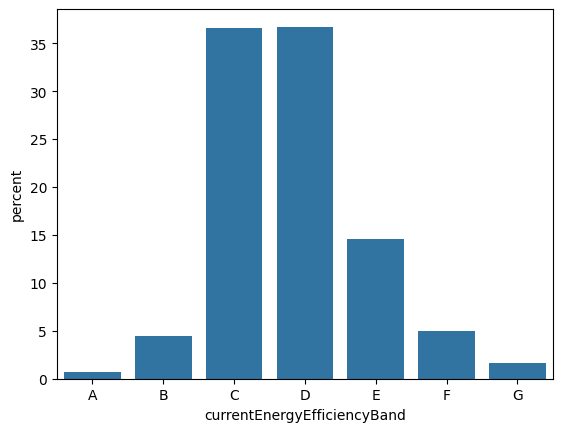

In [25]:

# check distribution of target variable
sns.countplot(data=data_frame, x="currentEnergyEfficiencyBand", stat="percent")

# Compare the constituency Beaconsfield to London

In [27]:
newSearch.constituency = "Cities of London and Westminster"

data = API.get_data(Search.path,**newSearch.params)
next_data_frame = pd.DataFrame(data['data'])


200


In [28]:
# London Shape
next_data_frame.shape

(3515, 13)

In [29]:
next_data_frame.isnull().sum()

certificateNumber                 0
addressLine1                   1683
addressLine2                    113
addressLine3                    912
addressLine4                   3126
postcode                          0
postTown                          0
council                           0
constituency                      0
currentEnergyEfficiencyBand       9
registrationDate                  0
uprn                            507
schemaType                        0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

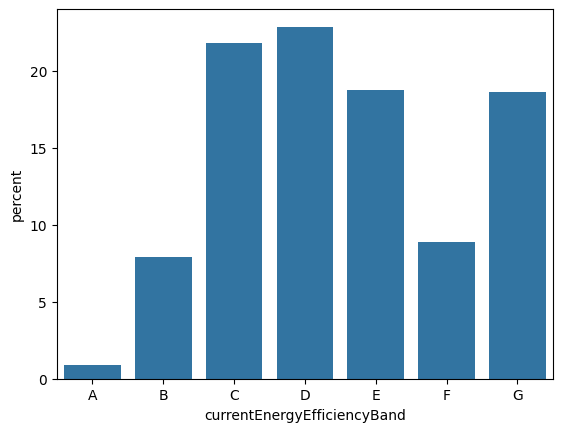

In [41]:
sns.countplot(data=next_data_frame.sort_values(by="currentEnergyEfficiencyBand"), x="currentEnergyEfficiencyBand", stat="percent")

In [ ]:
# sub-urban vs urban data 
full_data = pd.concat([data_frame,next_data_frame],ignore_index=True)
full_data.shape

(4193, 13)

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='proportion'>

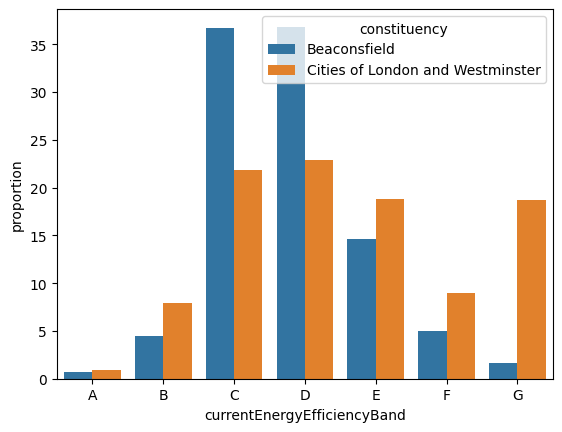

In [ ]:
# Make beaconsfield proportionate to london to do an efficiency comparison
comparison = full_data.groupby("constituency")["currentEnergyEfficiencyBand"].value_counts(normalize=True).mul(100).sort_index().reset_index()

sns.barplot( data=comparison, x="currentEnergyEfficiencyBand", y="proportion", hue="constituency")
# sns.countplot(data=new, x="currentEnergyEfficiencyBand", stat="percent",hue="constituency")